# Getting Stock Data with APIs
**Learn to fetch real stock prices and create simple visualizations**

## What You'll Build
A simple tool that gets stock price data from a free API and creates a basic chart using pandas plotting.

## Setup

In [5]:
# Install what we need
!pip install pandas requests matplotlib

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 4.5 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.2 MB 5.4 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.2 MB 5.4 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.2 MB 5.4 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.2 MB 4.8 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.2 MB 4.6 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.2 MB 4.3 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 4.2 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.2 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 3.8 MB/s  0:00:02
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------- -----------------

In [6]:
# Import libraries
import pandas as pd
import requests
import matplotlib.pyplot as plt
from datetime import datetime

Matplotlib is building the font cache; this may take a moment.


## Step 1: Ask AI to Help Choose a Stock API

Let's start by asking Colab's AI about free stock APIs. But for this tutorial, we'll simulate the conversation.
```
Ask Colab AI: 'What are some free stock APIs I can use for learning? I want to get basic stock price data.'

AI Response would suggest options like:
- Alpha Vantage (free tier)
- Yahoo Finance (via yfinance)
- IEX Cloud (free tier)
- Finnhub (free tier)
```
For this tutorial, we'll use Alpha Vantage since it's beginner-friendly.

## Step 2: Ask AI to Help Build the API Call

Let's ask AI to help us structure the API request, you might get something like

In [9]:
def get_stock_data(symbol, api_key="BER9R7TO5F6ZBEOKU"):
    base_url = "https://www.alphavantage.co/query"

   
    params = {
        'function': 'TIME_SERIES_DAILY',
        'symbol': symbol,
        'apikey': api_key,
        'outputsize': 'compact' 
    }

    response = requests.get(base_url, params=params)
    data = response.json()

    time_series = data.get("Time Series (Daily)", {})

    df = pd.DataFrame.from_dict(time_series, orient='index')
    df = df.astype(float)
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)

    return df

In [12]:
df = get_stock_data("IBM")  # or "AAPL"
df.head()

,1. open,2. high,3. low,4. close,5. volume
2025-12-01,306.505,307.1200,302.800,305.67,3166555.0
2025-12-02,307.000,310.4675,301.570,301.78,4261100.0
2025-12-03,302.880,303.9700,298.905,302.62,3953390.0
2025-12-04,302.875,309.6100,302.540,307.99,2962463.0
2025-12-05,308.590,311.8300,307.180,307.94,2344667.0


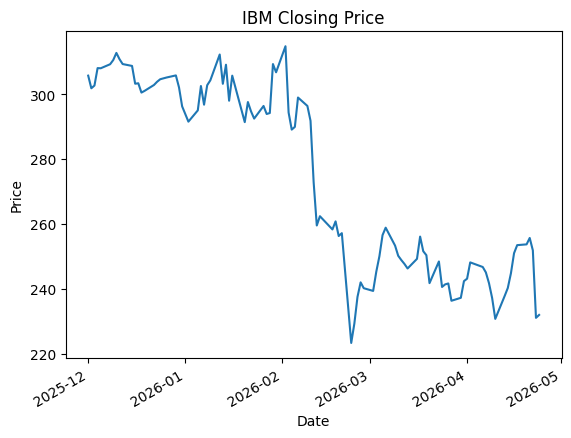

In [14]:
df['4. close'].plot(title="IBM Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

Alpha Vantage keeps that key just for quick tests, and it only gives you a small sample (IBM daily data) or sometimes just the “Information” notice you’re seeing.

What to do

Sign up (free)
Go to https://www.alphavantage.co/support/#api-key
 and enter your email.
They immediately email you a personal API key—no credit card, no waiting.

Use your key in the code
Replace the default "demo" with the key you receive:
```python
stock_data = get_stock_data("IBM", api_key="YOUR_REAL_KEY_HERE")
print(stock_data.keys())
```

or edit the function call everywhere you need it.

Respect their limits
* The free tier allows 5 calls per minute and 500 calls per day.
* If you need more, they have paid plans.

Once you use your own key, the "Information" message will be replaced with real stock data in the usual "Meta Data" and "Time Series (Daily)" fields.

## Step 3: Ask AI to Help Parse the Data

Can you think of a prompt to the AI to help write the function?  The API returns JSON. Let's ask AI how to convert it to a pandas DataFrame:

In [ ]:
def parse_stock_data(stock_data, symbol):
    """Convert API response to pandas DataFrame"""

    # Check if we got valid data
    if "Time Series (Daily)" not in stock_data:
        print("Error: No stock data found")
        print("Available keys:", list(stock_data.keys()))
        return None

    # Extract the time series data
    time_series = stock_data["Time Series (Daily)"]

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(time_series, orient='index')

    # Clean up column names
    df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

    # Convert to numeric
    df = df.astype(float)

    # Convert index to datetime
    df.index = pd.to_datetime(df.index)

    # Sort by date
    df = df.sort_index()

    # Add symbol column
    df['Symbol'] = symbol

    return df

# Parse the stock data
df = parse_stock_data(stock_data, "IBM")

if df is not None:
    print("Stock data sample:")
    print(df.head())
    print(f"\nData shape: {df.shape}")
else:
    print("Could not parse stock data")

## Step 4: Ask AI to Help Create a Simple Chart

Try this prompt (can you make it better?):

```
How do I create a simple line chart of stock prices using pandas?
```

You might get something like.  Now let's visualize the data:

In [17]:
def plot_stock_price(df, symbol):
    if df is None or df.empty:
        print("No data to plot")
        return

    # One-liner chart: pandas handles everything
    df['Close'].plot(title=f"{symbol} Stock Price").figure.show()

    # Basic stats
    print(f"\n{symbol} Stats")
    print("Latest:", df['Close'].iloc[-1])
    print("High:",   df['Close'].max())
    print("Low:",    df['Close'].min())


In [19]:
df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']


IBM Stats
Latest: 231.98
High: 314.73
Low: 223.35


C:\Users\razen\AppData\Local\Temp\ipykernel_15740\650718783.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  df['Close'].plot(title=f"{symbol} Stock Price").figure.show()


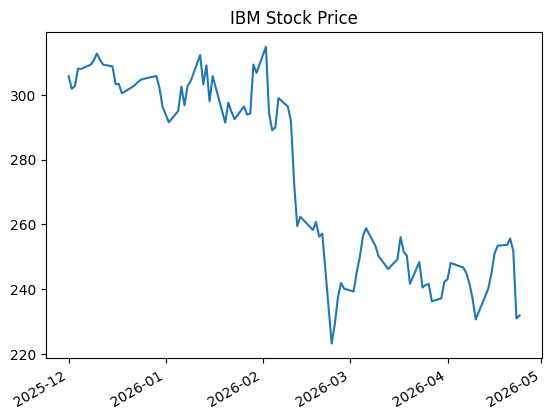

In [20]:
plot_stock_price(df, "IBM")

## Step 5: Extension Ideas

Let's expand to:
* compare multiple stocks
* build a simple analysis function (see earlier notebook)
* Real-time price updates
* More technical indicators (RSI, MACD)
* Portfolio tracking
* Price alerts
* Integration with a web interface
* Fundamental data (P/E ratios, etc.)
* News sentiment analysis



## Your Turn: Add a Feature

Try adding one feature with AI help:

In [24]:

def calculate_rsi(df, window=14):
    delta = df['Close'].diff()

    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta <0, 0)).rolling(window=window).mean()

    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    df['RSI'] = rsi
    return df
  

  

In [25]:
df = calculate_rsi(df)
df[['Close', 'RSI']].tail()

,Close,RSI
2026-04-20,253.71,66.055404
2026-04-21,255.68,63.817842
2026-04-22,251.86,58.522283
2026-04-23,231.08,37.238494
2026-04-24,231.98,38.885542


In [ ]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,8))

df['Close'].plot(ax=ax1, title="IBM Price")
df['RSI'].plot(ax=ax2, title="RSI Indicator")

ax2.axhline(70, linestyle='--') #Overbought
ax2.axhline(30, linestyle='--') #Oversold

plt.tight_layout

## Key Takeaways

You've built a stock analysis tool that:
- Fetches real stock data from an API
- Converts JSON to pandas DataFrames
- Creates visualizations of stock prices
- Calculates basic financial metrics
- Compares multiple stocks

This demonstrates core skills for financial applications:
- API integration
- Data processing with pandas
- Basic financial analysis
- Data visualization

## Next Steps

- Get a real Alpha Vantage API key for more data
- Add more technical indicators
- Combine with the chatbot tutorial
- Build a Gradio interface for user interaction
- Integrate with portfolio tracking

The foundation you've built here can be extended into sophisticated financial analysis tools!